In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


## Data preprocessing


### 1. Handle missing values

In [6]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [7]:
df['Income'] = df['Income'].fillna(df['Income'].median())

### 2. Feature Engineering

In [8]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [9]:
df['Age'] = 2026-df['Year_Birth']

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [11]:
# Customer Joining Date

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
reference_date = df['Dt_Customer'].max()
df['Customer_Tenure_Days'] = (reference_date - df['Dt_Customer']).dt.days

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [13]:
# Spending..

df['Total_Spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +df['MntSweetProducts'] + df['MntFishProducts']+ df['MntGoldProds']
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [14]:
# Children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [15]:
# Education
df['Education'].value_counts()

,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


In [16]:
df['Education'] = df['Education'].replace({
    'Basic':'Undergraduate',
    '2n Cycle':'Undergraduate',
    'Graduation':'Graduate',
    'Master':'Postgraduate',
    'PhD':'Postgraduate'
})

df['Education'].value_counts()

,count
Education,
Graduate,1127
Postgraduate,856
Undergraduate,257


In [17]:
# Marital Status

df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


In [18]:
df['Living_with'] = df['Marital_Status'].replace({
    'Married':'Partner',
    'Together':'Partner',

    'Divorced':'Alone',
    'Single':'Alone',
    'YOLO':'Alone',
    'Absurd':'Alone',
    'Widow':'Alone',
})
df['Living_with'].value_counts()

,count
Living_with,
Partner,1444
Alone,796


### 3. Drop Columns



In [19]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_with'],
      dtype='object')

In [20]:
remove_columns = ['ID', 'Year_Birth', "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer" ]
Spending_cols = ["MntWines", 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

cols_to_drop = remove_columns + Spending_cols
df_cleaned = df.drop(columns=cols_to_drop)
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [21]:
df_cleaned.shape

(2240, 15)

### 4. Outliers

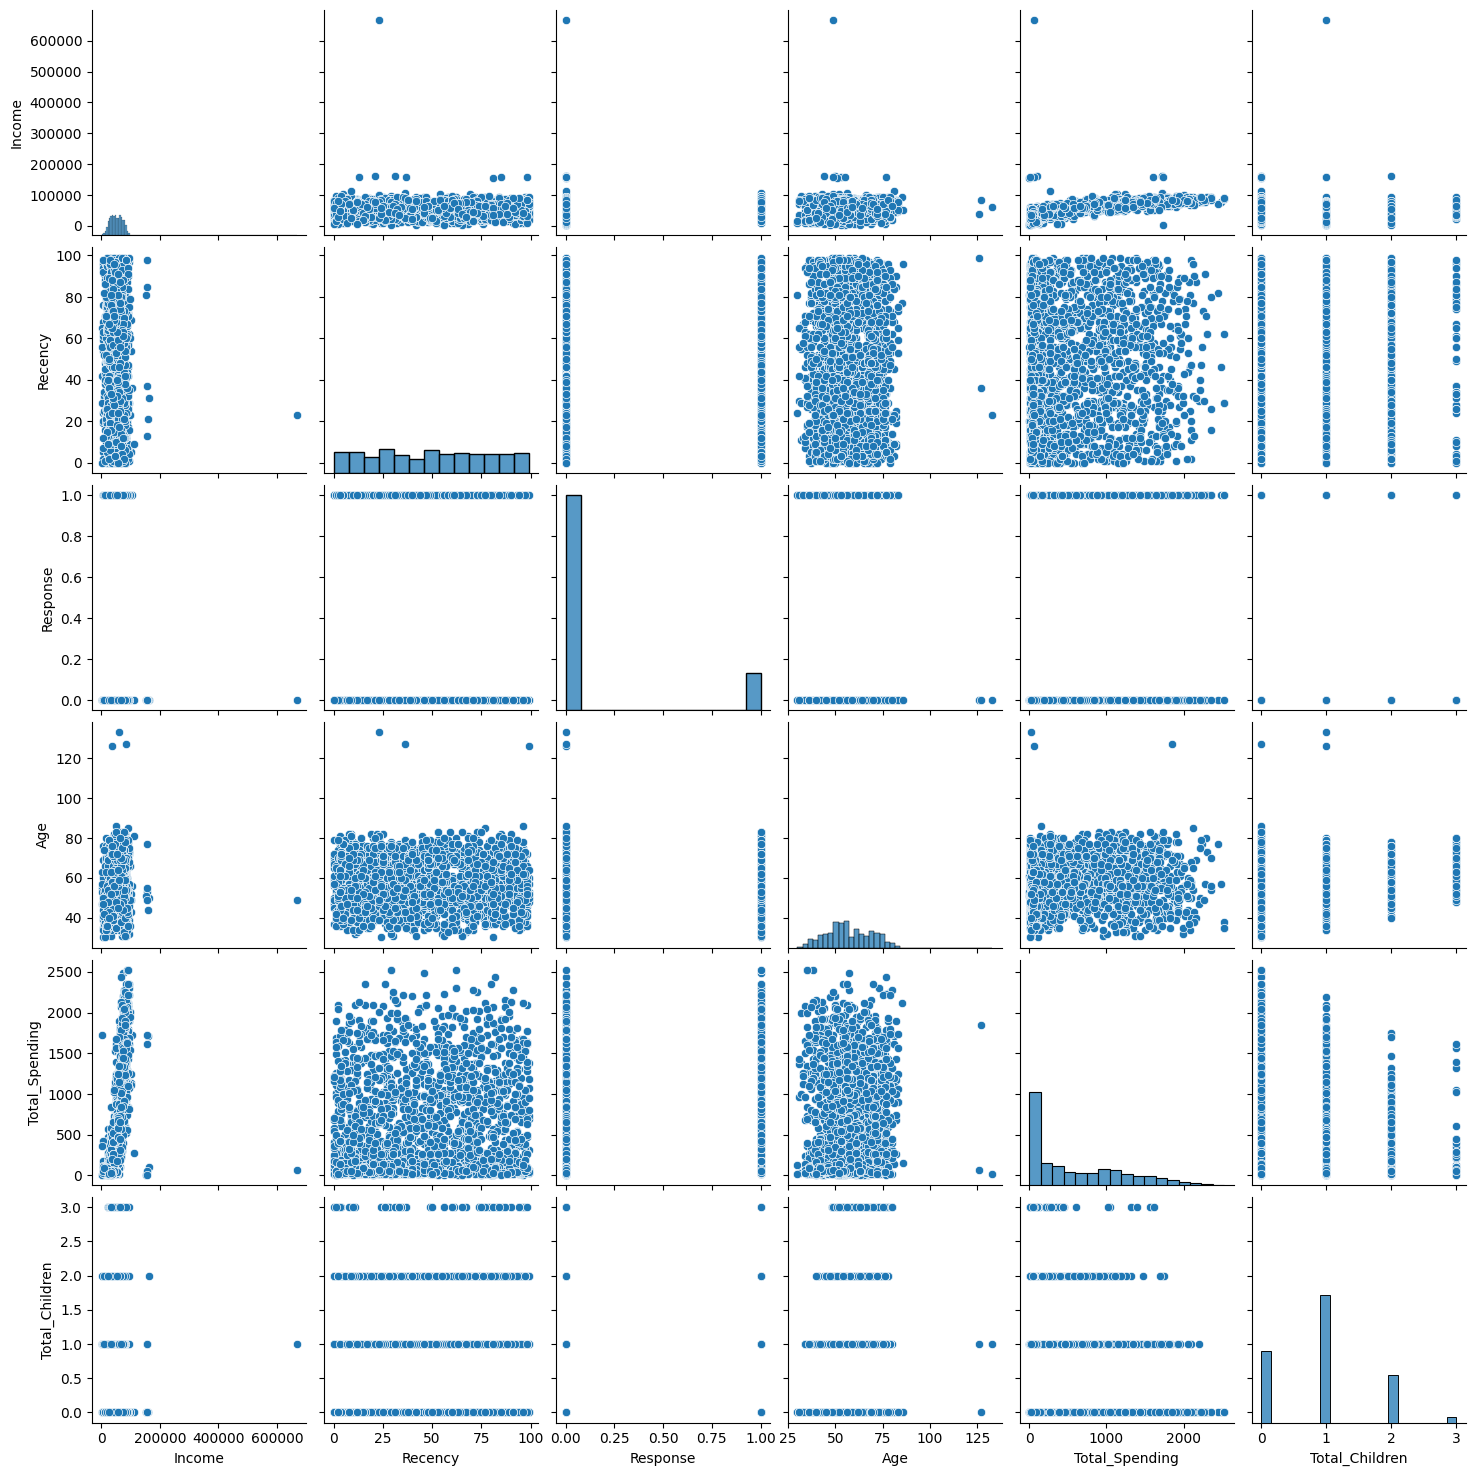

In [22]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

sns.pairplot(df_cleaned[cols])

In [23]:
print("Data size with outlier : ", len(df_cleaned))
df_cleaned = df_cleaned[ (df_cleaned ["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000)]

print("Without Outliers", len(df_cleaned))

Data size with outlier :  2240
Without Outliers 2236


### Heatmap

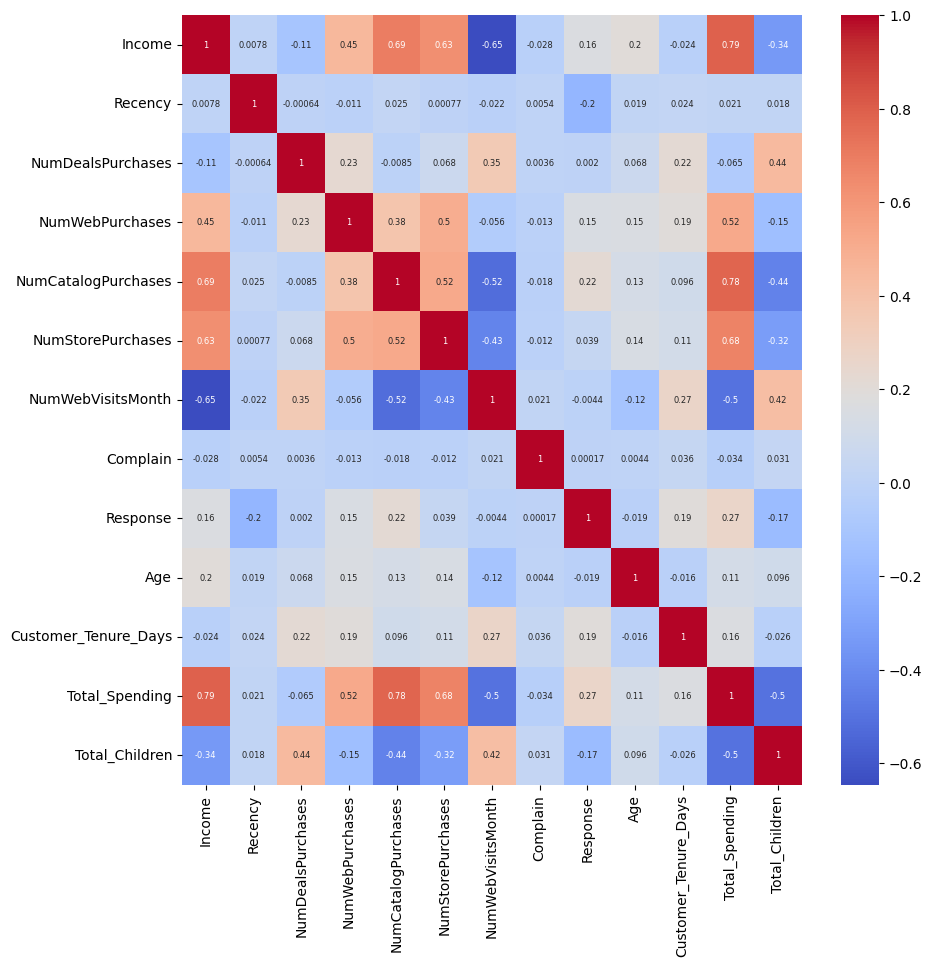

In [24]:
corr = df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, annot_kws = {"size" : 6},cmap='coolwarm')
plt.show()


### Encoding..

In [25]:
from sklearn.preprocessing import OneHotEncoder

In [26]:
ohe = OneHotEncoder()
cat_cols = ["Education", "Living_with"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [27]:
enc_df = pd.DataFrame(
            enc_cols.toarray(),
            columns=ohe.get_feature_names_out(cat_cols),
            index=df_cleaned.index)
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [28]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


### Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
X = df_encoded

In [31]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

### Visualize

In [32]:
# 3D
from sklearn.decomposition import PCA

In [33]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D projection')

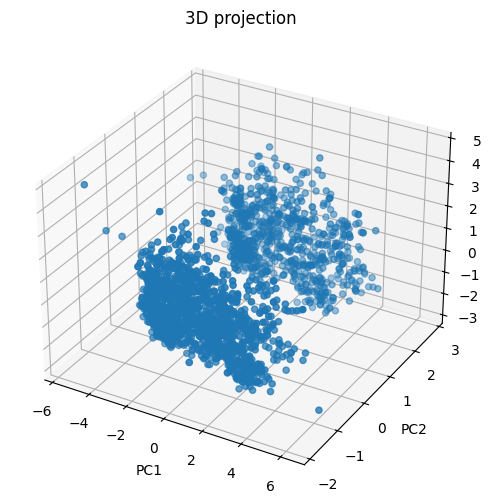

In [34]:
# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:,1], X_pca[:, 2])

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

ax.set_title('3D projection')

### Analyze K value

#### 1. Elbow Method

In [35]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit_predict(X_pca)
  wcss.append(kmeans.inertia_)

In [36]:
Knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
optimal_k = Knee.elbow
print("Best k = ", optimal_k)

Best k =  4


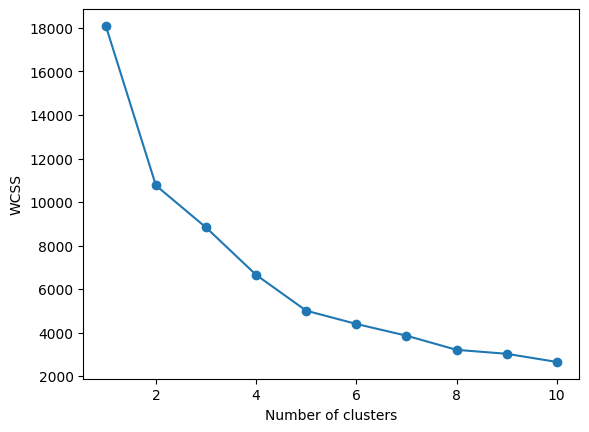

In [37]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

#### 2. Silhouette Score

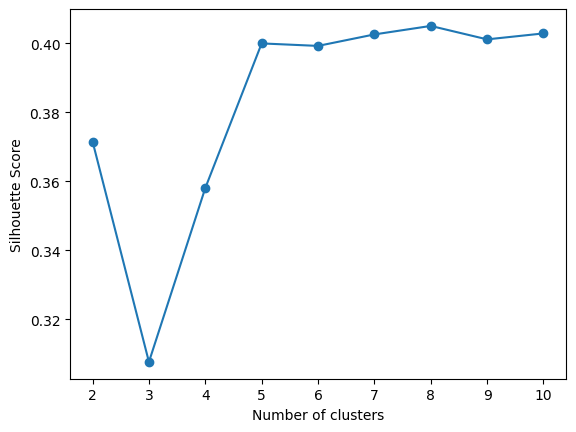

In [38]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 11):
  Kmeans = KMeans(n_clusters=k, random_state=42)
  labels = Kmeans.fit_predict(X_pca)
  score = silhouette_score(X_pca, labels)
  scores.append(score)

#plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

Text(0, 0.5, 'Silhouette Score')

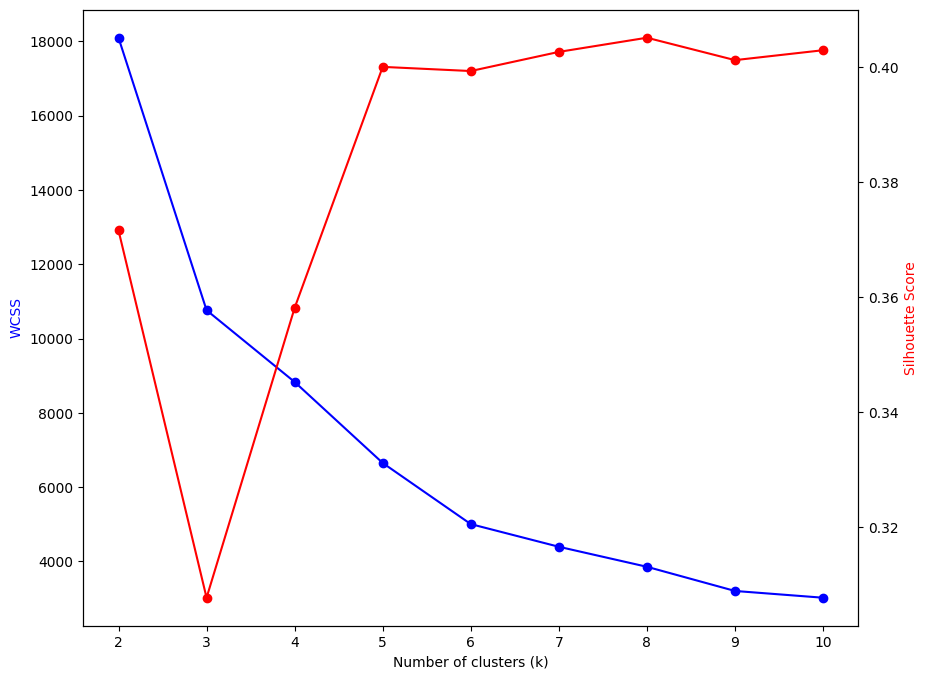

In [39]:
# Combine plot

K_range = range(2, 11)
fig, ax1 = plt.subplots(figsize=(10, 8))

# Elbow Plot
ax1.plot(K_range, wcss[: len(K_range)], marker='o', color='blue')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('WCSS', color='blue')

# Silhouette plot
ax2 = ax1.twinx()
ax2.plot(K_range, scores[: len(K_range)], marker='o', color='red')
ax2.set_ylabel('Silhouette Score', color='red')

# Clustering

## 1.  K means

In [40]:
Kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = Kmeans.fit_predict(X_pca)

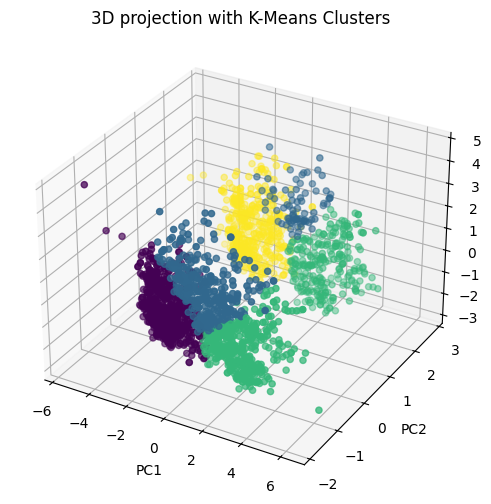

In [41]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:,1], X_pca[:, 2], c=labels_kmeans, cmap='viridis')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D projection with K-Means Clusters')
plt.show()

## 2. Agglomerative Clustering



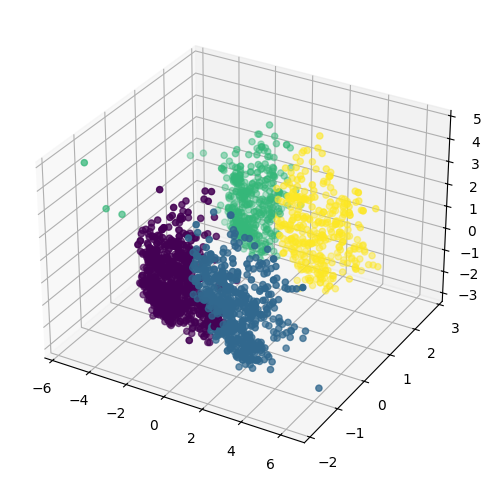

In [42]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agglo = agglo.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:,1], X_pca[:,2], c=labels_agglo, cmap='viridis')


### Conlusion : Agglomerative Clustering is Better

### Characterization of Clusters

In [43]:
X['Clusters'] = labels_agglo

In [44]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,Clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Clusters', ylabel='count'>

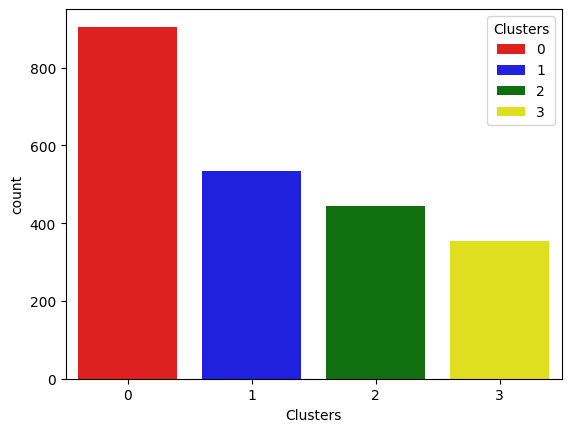

In [45]:
pal = ["red", "blue", "green", "yellow"]
sns.countplot(x=X['Clusters'], palette=pal, hue=X['Clusters'])

<Axes: xlabel='Total_Spending', ylabel='Income'>

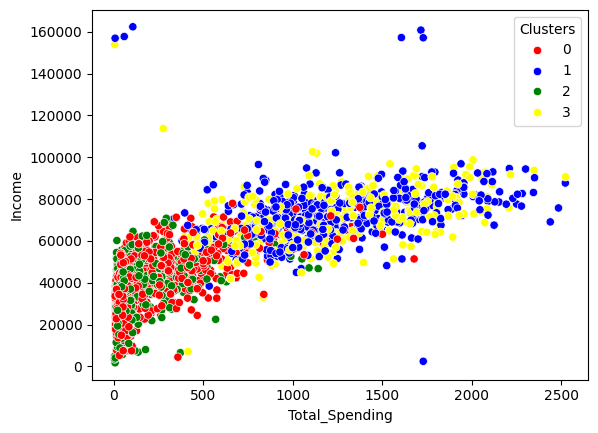

In [46]:
# Income & Spending Patterns

sns.scatterplot(x=X['Total_Spending'], y=X['Income'], hue=X['Clusters'], palette=pal)

In [47]:
# cluster summary

cluster_summary = X.groupby('Clusters').mean()
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
Clusters,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000


### Cluster Analysis
```
After applying Agglomerative Clustering, the algorithm assigned numerical labels
(0, 1, 2, and 3) to represent different customer groups.

To understand the characteristics of each cluster, we computed the average values
of key features such as income, spending behaviour, purchase frequency,
customer engagement, and household characteristics.

This cluster summary helps us interpret the behaviour of customers in each group.
Based on these patterns, we can assign meaningful business-friendly names
to the clusters to make the segmentation easier to understand.```

In [48]:
cluster_names = {
    0: "Budget Families",
    1: "Premium Customers",
    2: "Low Engagement Customers",
    3: "Loyal High Spenders"
}

X['Cluster_Name'] = X['Clusters'].map(cluster_names)

In [49]:
X[['Clusters','Cluster_Name']].head()

,Clusters,Cluster_Name
0,3,Loyal High Spenders
1,2,Low Engagement Customers
2,1,Premium Customers
3,0,Budget Families
4,0,Budget Families


/tmp/ipykernel_23145/1435281063.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster_Name', data=X, palette='Set2')


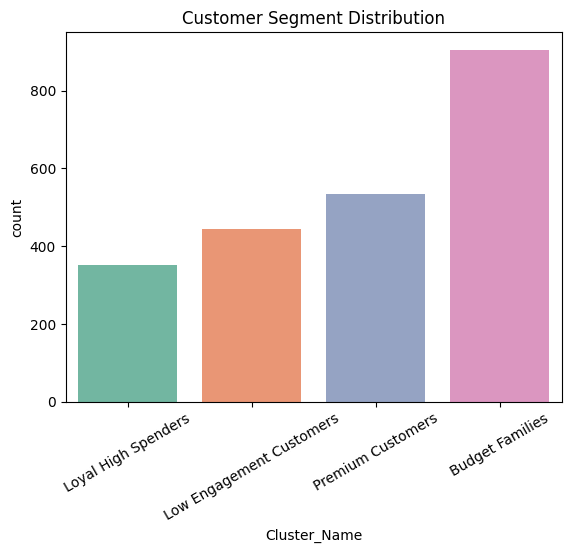

In [50]:
sns.countplot(x='Cluster_Name', data=X, palette='Set2')
plt.xticks(rotation=30)
plt.title("Customer Segment Distribution")
plt.show()

In [51]:
cluster_summary_named = X.groupby('Cluster_Name').mean()
print(cluster_summary_named)

                                Income    Recency  NumDealsPurchases  \
Cluster_Name                                                           
Budget Families           39680.580110  48.914917           2.594475   
Low Engagement Customers  36960.143018  48.319820           2.594595   
Loyal High Spenders       70722.681303  50.504249           1.855524   
Premium Customers         72808.445693  49.202247           1.958801   

                          NumWebPurchases  NumCatalogPurchases  \
Cluster_Name                                                     
Budget Families                  3.153591             0.969061   
Low Engagement Customers         2.713964             0.837838   
Loyal High Spenders              5.790368             5.014164   
Premium Customers                5.687266             5.498127   

                          NumStorePurchases  NumWebVisitsMonth  Complain  \
Cluster_Name                                                               
Budget Families   

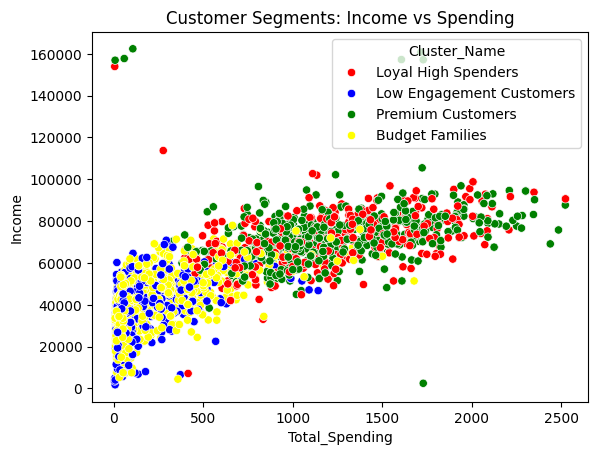

In [52]:
sns.scatterplot(
    x=X['Total_Spending'],
    y=X['Income'],
    hue=X['Cluster_Name'],
    palette=pal
)

plt.title("Customer Segments: Income vs Spending")
plt.show()

## Conclusion

In this project, customer segmentation was performed using unsupervised machine learning
techniques to identify different groups of customers based on their purchasing behaviour,
demographics, and engagement patterns.

Using clustering algorithms, four distinct customer segments were identified:

- **Budget Families** – Customers with lower income and moderate spending, often having more children.
- **Low Engagement Customers** – Customers with low spending and low purchase activity despite visiting the platform.
- **Premium Customers** – High income customers with high spending and frequent purchases.
- **Loyal High Spenders** – Highly engaged customers with high spending and strong response to campaigns.

These segments help businesses better understand customer behaviour and design targeted
marketing strategies for each group. By applying personalized promotions, loyalty programs,
and engagement strategies, SmartCart can improve customer retention and increase revenue.